---
## Part A: Continuation from Assignment 3
This notebook is a direct continuation of Assignment 3. We reuse:
- The same cleaned dataset: `global_air_quality_dataset.csv`
- The `AQI` column for defining RL states
- The `AQI Category` logic (Good, Moderate, Unhealthy, etc.) created in Assignment 3

**GitHub Repo:** https://github.com/aman16siddiqui-creator/AQI-Data-Science-Project

In [10]:
# Add this at the top of the notebook (Cell 1), after imports:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [9]:

# 2: Load the Cleaned Dataset (Google Colab version)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/global_air_quality_dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset loaded successfully!
Shape: (3660, 13)
Columns: ['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [11]:
# 3: Verify AQI Column & Recreate AQI Category (from Assignment 3) ────
print("AQI column statistics:")
print(df['AQI'].describe())

# Recreate AQI Category (same function used in Assignment 3)
def categorize_aqi(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI Category'] = df['AQI'].apply(categorize_aqi)
print("\nAQI Category distribution (reused from Assignment 3):")
print(df['AQI Category'].value_counts())

AQI column statistics:
count    3660.000000
mean      164.642077
std        78.571659
min        30.000000
25%        96.000000
50%       165.000000
75%       233.000000
max       300.000000
Name: AQI, dtype: float64

AQI Category distribution (reused from Assignment 3):
AQI Category
Very Unhealthy                    1360
Moderate                           673
Unhealthy                          666
Unhealthy for Sensitive Groups     664
Good                               297
Name: count, dtype: int64


In [12]:
# ── CELL 4: Summary of What Is Being Reused from Assignment 3 ─────────────────
print("=" * 55)
print("  Assignment 3 Outputs Reused in Assignment 4")
print("=" * 55)
print(f"  Cleaned Dataset        : global_air_quality_dataset.csv")
print(f"  Total Records          : {len(df)}")
print(f"  AQI Column             : 'AQI' (numerical values)")
print(f"  AQI Category Column    : 'AQI Category' (6 categories)")
print(f"  Pollutant Features     : PM2.5, PM10, CO, NO2, O3, SO2")
print(f"  City / Country Fields  : Used for optional analysis")
print("=" * 55)

  Assignment 3 Outputs Reused in Assignment 4
  Cleaned Dataset        : global_air_quality_dataset.csv
  Total Records          : 3660
  AQI Column             : 'AQI' (numerical values)
  AQI Category Column    : 'AQI Category' (6 categories)
  Pollutant Features     : PM2.5, PM10, CO, NO2, O3, SO2
  City / Country Fields  : Used for optional analysis


---
## Part B: Define the Reinforcement Learning Components

| RL Component | Definition in This Assignment |
|---|---|
| **Agent** | The adaptive traffic-control decision maker |
| **Environment** | AQI conditions taken from the cleaned AQI dataset |
| **State** | AQI condition: Low (≤100), Medium (101–200), High (>200) |
| **Action** | 0 = No Restriction, 1 = Partial Restriction, 2 = High-Pollution Alert |
| **Reward** | A score that encourages correct action and penalizes wrong action |
| **Policy** | Learned mapping from AQI state → best action |
| **Episode** | One training cycle where agent interacts with multiple AQI records |

---
## Part C: AQI State Creation (3-State Design)

In [13]:
# ── CELL 5: Create RL States from AQI Values ──────────────────────────────────
def get_rl_state(aqi):
    """Map AQI numerical value to RL state (0=Low, 1=Medium, 2=High)"""
    if aqi <= 100:
        return 0   # Low AQI
    elif aqi <= 200:
        return 1   # Medium AQI
    else:
        return 2   # High AQI

df['RL_State'] = df['AQI'].apply(get_rl_state)

state_labels = {0: 'Low AQI (≤100)', 1: 'Medium AQI (101-200)', 2: 'High AQI (>200)'}

print("RL State Distribution:")
for s, label in state_labels.items():
    count = (df['RL_State'] == s).sum()
    print(f"  State {s} - {label}: {count} records ({count/len(df)*100:.1f}%)")

RL State Distribution:
  State 0 - Low AQI (≤100): 970 records (26.5%)
  State 1 - Medium AQI (101-200): 1330 records (36.3%)
  State 2 - High AQI (>200): 1360 records (37.2%)


---
## Part D: Action Space

| Action ID | Action Name | Meaning |
|---|---|---|
| 0 | No Restriction | Normal traffic flow; no public warning |
| 1 | Partial Restriction | Moderate control: reduce heavy traffic, advise sensitive groups |
| 2 | High-Pollution Alert | Strong warning during dangerous AQI conditions |

---
## Part E: Reward System

In [14]:
# ── CELL 6: Define the Reward Table ───────────────────────────────────────────
# reward_table[state][action] = reward value
# Actions: 0=No Restriction, 1=Partial Restriction, 2=High-Pollution Alert
reward_table = {
    0: [+10, -2,  -5],   # Low AQI   → best action = 0 (No Restriction)
    1: [ -6, +10, +2],   # Medium AQI→ best action = 1 (Partial Restriction)
    2: [-10, -3, +10]    # High AQI  → best action = 2 (High-Pollution Alert)
}

action_names = ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']
state_names  = ['Low AQI', 'Medium AQI', 'High AQI']

print("Reward Table:")
print(f"{'State':<15} {'No Restriction':>15} {'Partial Restriction':>20} {'High-Pollution Alert':>22} {'Best Action':>15}")
print("-" * 87)
best_actions = {0: 'No Restriction', 1: 'Partial Restriction', 2: 'High-Pollution Alert'}
for s, rewards in reward_table.items():
    print(f"{state_names[s]:<15} {rewards[0]:>15} {rewards[1]:>20} {rewards[2]:>22} {best_actions[s]:>15}")

Reward Table:
State            No Restriction  Partial Restriction   High-Pollution Alert     Best Action
---------------------------------------------------------------------------------------
Low AQI                      10                   -2                     -5  No Restriction
Medium AQI                   -6                   10                      2 Partial Restriction
High AQI                    -10                   -3                     10 High-Pollution Alert


---
## Part F: Q-Learning Implementation

In [15]:
# ── CELL 7: Initialize Q-Table and Hyperparameters ────────────────────────────
NUM_STATES  = 3   # Low, Medium, High
NUM_ACTIONS = 3   # No Restriction, Partial Restriction, High-Pollution Alert

# Hyperparameters
alpha   = 0.1    # Learning rate
gamma   = 0.9    # Discount factor
epsilon = 0.2    # Exploration rate (20% explore, 80% exploit)
episodes = 1000  # Training episodes

# Initialize Q-table with zeros
Q = np.zeros((NUM_STATES, NUM_ACTIONS))

print("Q-Table initialized (all zeros):")
q_df = pd.DataFrame(Q, columns=action_names, index=state_names)
print(q_df)
print(f"\nHyperparameters:")
print(f"  Alpha (learning rate)    : {alpha}")
print(f"  Gamma (discount factor)  : {gamma}")
print(f"  Epsilon (exploration)    : {epsilon}")
print(f"  Episodes                 : {episodes}")

Q-Table initialized (all zeros):
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI                0.0                  0.0                   0.0
Medium AQI             0.0                  0.0                   0.0
High AQI               0.0                  0.0                   0.0

Hyperparameters:
  Alpha (learning rate)    : 0.1
  Gamma (discount factor)  : 0.9
  Epsilon (exploration)    : 0.2
  Episodes                 : 1000


In [16]:
# ── CELL 8: Q-Learning Training Loop ──────────────────────────────────────────
np.random.seed(42)
random.seed(42)

# Convert RL states to a list for sampling
state_list = df['RL_State'].tolist()

rewards_per_episode = []
action_counts = [0, 0, 0]  # Count of each action selected

for episode in range(episodes):
    # Sample a random batch of AQI records for this episode
    episode_states = random.choices(state_list, k=50)
    total_reward = 0

    for i in range(len(episode_states) - 1):
        state      = episode_states[i]
        next_state = episode_states[i + 1]

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.randint(NUM_ACTIONS)   # Explore
        else:
            action = np.argmax(Q[state])              # Exploit

        # Get reward from reward table
        reward = reward_table[state][action]
        total_reward += reward
        action_counts[action] += 1

        # Q-learning update rule:
        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s')) - Q(s,a)]
        Q[state][action] = Q[state][action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state][action]
        )

    rewards_per_episode.append(total_reward)

print(f"✅ Training complete! ({episodes} episodes)")
print(f"   Average reward (last 100 episodes): {np.mean(rewards_per_episode[-100:]):.2f}")
print(f"   Overall average reward             : {np.mean(rewards_per_episode):.2f}")

✅ Training complete! (1000 episodes)
   Average reward (last 100 episodes): 399.45
   Overall average reward             : 398.97


In [17]:
# ── CELL 9: Extract Learned Policy ────────────────────────────────────────────
print("Final Q-Table (Learned Values):")
q_df_final = pd.DataFrame(Q, columns=action_names, index=state_names)
print(q_df_final.round(3))

print("\nLearned Policy (Best Action per State):")
print("-" * 50)
for s in range(NUM_STATES):
    best = np.argmax(Q[s])
    print(f"  {state_names[s]:<15} → {action_names[best]}")

Final Q-Table (Learned Values):
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI              100.0                 88.0                  85.0
Medium AQI            84.0                100.0                  92.0
High AQI              80.0                 87.0                 100.0

Learned Policy (Best Action per State):
--------------------------------------------------
  Low AQI         → No Restriction
  Medium AQI      → Partial Restriction
  High AQI        → High-Pollution Alert


---
## Part G: Simulation and Evaluation

In [18]:
# ── CELL 10: Test on Unseen Sample ────────────────────────────────────────────
test_sample = df.sample(n=300, random_state=99)
test_states = test_sample['RL_State'].tolist()

test_rewards = []
test_actions = []

for state in test_states:
    action = np.argmax(Q[state])          # Pure exploitation (no exploration)
    reward = reward_table[state][action]
    test_rewards.append(reward)
    test_actions.append(action)

print(f"Test Sample Size       : {len(test_states)}")
print(f"Average Reward (test)  : {np.mean(test_rewards):.2f}")
print(f"\nAction distribution on test data:")
for a, name in enumerate(action_names):
    count = test_actions.count(a)
    print(f"  {name:<22}: {count} ({count/len(test_actions)*100:.1f}%)")

Test Sample Size       : 300
Average Reward (test)  : 10.00

Action distribution on test data:
  No Restriction        : 92 (30.7%)
  Partial Restriction   : 103 (34.3%)
  High-Pollution Alert  : 105 (35.0%)


In [19]:
# ── CELL 11: Policy Comparison Table ──────────────────────────────────────────
expected = ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']

print("Policy Comparison Table:")
print("-" * 65)
print(f"{'AQI State':<15} {'Expected Action':<25} {'Learned Action':<25} {'Correct?'}")
print("-" * 65)
for s in range(NUM_STATES):
    learned = action_names[np.argmax(Q[s])]
    correct = '✅ Yes' if learned == expected[s] else '❌ No'
    print(f"{state_names[s]:<15} {expected[s]:<25} {learned:<25} {correct}")

Policy Comparison Table:
-----------------------------------------------------------------
AQI State       Expected Action           Learned Action            Correct?
-----------------------------------------------------------------
Low AQI         No Restriction            No Restriction            ✅ Yes
Medium AQI      Partial Restriction       Partial Restriction       ✅ Yes
High AQI        High-Pollution Alert      High-Pollution Alert      ✅ Yes


---
## Part H: Required Visualizations

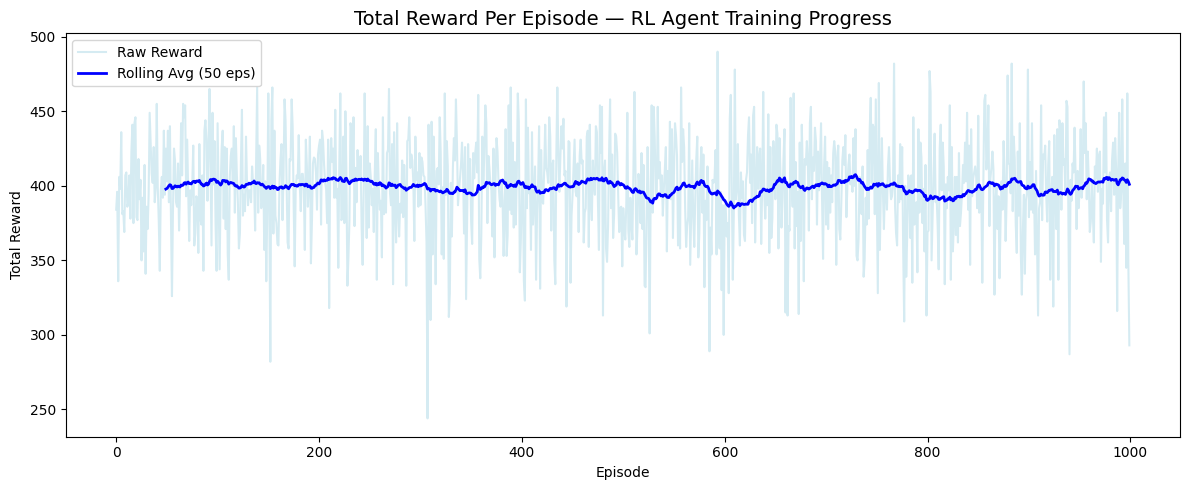

Explanation: This chart shows how the agent's total reward changes over 1000 episodes. An upward trend in the rolling average confirms that the agent is learning and improving its decision-making policy over time.


In [20]:
# ── CELL 12: Visualization 1 — Total Reward Per Episode ───────────────────────
# Smooth with rolling average for clarity
rolling_avg = pd.Series(rewards_per_episode).rolling(window=50).mean()

plt.figure(figsize=(12, 5))
plt.plot(rewards_per_episode, color='lightblue', alpha=0.5, label='Raw Reward')
plt.plot(rolling_avg, color='blue', linewidth=2, label='Rolling Avg (50 eps)')
plt.title('Total Reward Per Episode — RL Agent Training Progress', fontsize=14)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/reward_plot.png', dpi=150)
plt.show()
print("Explanation: This chart shows how the agent's total reward changes over 1000 episodes."
      " An upward trend in the rolling average confirms that the agent is learning and improving"
      " its decision-making policy over time.")

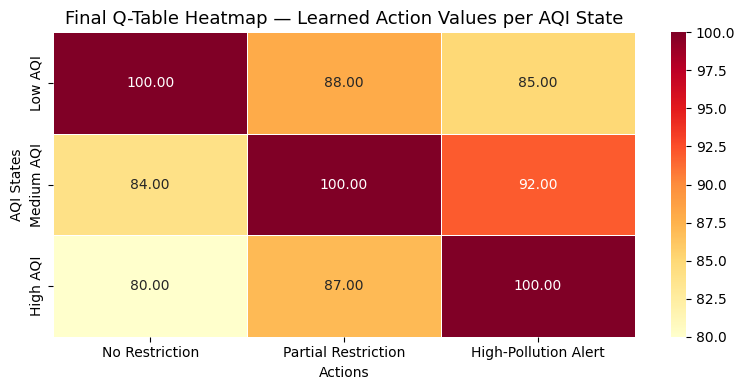

Explanation: Each cell shows the Q-value (expected future reward) for a state-action pair. The brighter cells indicate the preferred action. The agent correctly learns high values for the diagonal: No Restriction for Low AQI, Partial Restriction for Medium, and High-Pollution Alert for High AQI.


In [21]:
# ── CELL 13: Visualization 2 — Final Q-Table Heatmap ─────────────────────────
plt.figure(figsize=(8, 4))
sns.heatmap(
    pd.DataFrame(Q, columns=action_names, index=state_names),
    annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5
)
plt.title('Final Q-Table Heatmap — Learned Action Values per AQI State', fontsize=13)
plt.xlabel('Actions')
plt.ylabel('AQI States')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/q_table_heatmap.png', dpi=150)
plt.show()
print("Explanation: Each cell shows the Q-value (expected future reward) for a state-action pair."
      " The brighter cells indicate the preferred action. The agent correctly learns high values"
      " for the diagonal: No Restriction for Low AQI, Partial Restriction for Medium, and"
      " High-Pollution Alert for High AQI.")

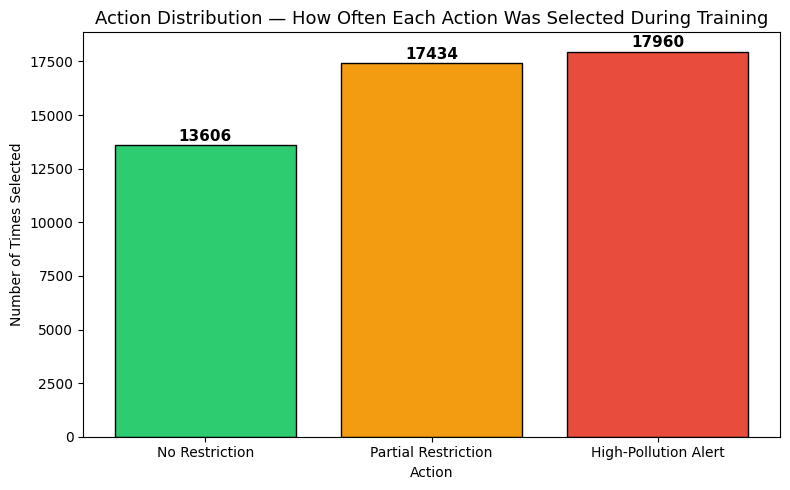

Explanation: This bar chart shows how frequently each traffic-control action was chosen throughout the entire training. A higher count for Partial Restriction and High-Pollution Alert is expected because the majority of the dataset has Medium and High AQI values.


In [22]:
# ── CELL 14: Visualization 3 — Action Distribution Chart ─────────────────────
colors = ['#2ecc71', '#f39c12', '#e74c3c']
plt.figure(figsize=(8, 5))
bars = plt.bar(action_names, action_counts, color=colors, edgecolor='black')
for bar, count in zip(bars, action_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(count), ha='center', fontsize=11, fontweight='bold')
plt.title('Action Distribution — How Often Each Action Was Selected During Training', fontsize=13)
plt.xlabel('Action')
plt.ylabel('Number of Times Selected')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/action_distribution.png', dpi=150)
plt.show()
print("Explanation: This bar chart shows how frequently each traffic-control action was chosen"
      " throughout the entire training. A higher count for Partial Restriction and High-Pollution Alert"
      " is expected because the majority of the dataset has Medium and High AQI values.")

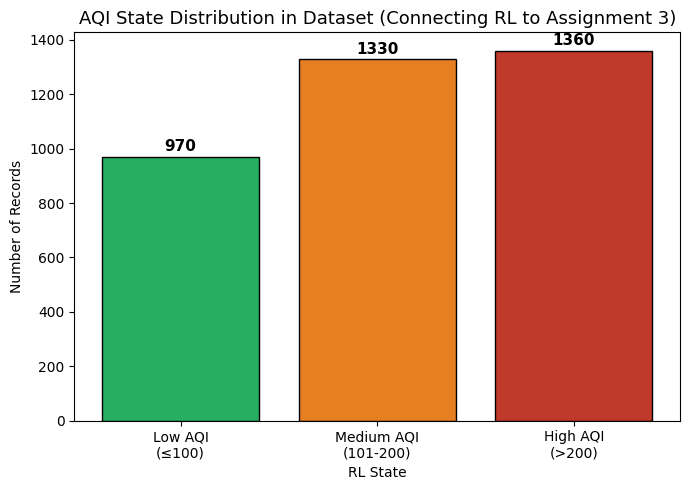

Explanation: This chart connects the RL task back to Assignment 3 by showing the distribution of AQI states in the dataset. Most records fall in Medium and High AQI, which means the agent sees more of those states during training.


In [23]:
# ── CELL 15: Optional Visualization 4 — AQI State Distribution ───────────────
state_counts = df['RL_State'].value_counts().sort_index()
state_plot_labels = ['Low AQI\n(≤100)', 'Medium AQI\n(101-200)', 'High AQI\n(>200)']

plt.figure(figsize=(7, 5))
plt.bar(state_plot_labels, state_counts.values,
        color=['#27ae60', '#e67e22', '#c0392b'], edgecolor='black')
for i, v in enumerate(state_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')
plt.title('AQI State Distribution in Dataset (Connecting RL to Assignment 3)', fontsize=13)
plt.xlabel('RL State')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/aqi_state_distribution.png', dpi=150)
plt.show()
print("Explanation: This chart connects the RL task back to Assignment 3 by showing the"
      " distribution of AQI states in the dataset. Most records fall in Medium and High AQI,"
      " which means the agent sees more of those states during training.")

In [24]:
# ── CELL 16: Save Q-Table as CSV ──────────────────────────────────────────────
import os
os.makedirs('../outputs/rl_results', exist_ok=True)

q_table_df = pd.DataFrame(Q, columns=action_names, index=state_names)
q_table_df.to_csv('/content/drive/MyDrive/q_table.csv')
print("✅ Q-table saved to outputs/rl_results/q_table.csv")

✅ Q-table saved to outputs/rl_results/q_table.csv


---
## Section 5: Final RL Result Tables

In [25]:
# ── CELL 17: Print Final Result Summary ───────────────────────────────────────
avg_reward_last100 = np.mean(rewards_per_episode[-100:])

print("=" * 55)
print("         FINAL RL RESULTS SUMMARY")
print("=" * 55)
print(f"  Number of states            : 3")
print(f"  Number of actions           : 3")
print(f"  Episodes used for training  : {episodes}")
print(f"  Learning rate (alpha)       : {alpha}")
print(f"  Discount factor (gamma)     : {gamma}")
print(f"  Exploration rate (epsilon)  : {epsilon}")
print(f"  Avg reward (last 100 eps)   : {avg_reward_last100:.2f}")
print("=" * 55)
print("\n  Final Learned Policy:")
for s in range(NUM_STATES):
    best = action_names[np.argmax(Q[s])]
    print(f"    {state_names[s]:<15} → {best}")

         FINAL RL RESULTS SUMMARY
  Number of states            : 3
  Number of actions           : 3
  Episodes used for training  : 1000
  Learning rate (alpha)       : 0.1
  Discount factor (gamma)     : 0.9
  Exploration rate (epsilon)  : 0.2
  Avg reward (last 100 eps)   : 399.45

  Final Learned Policy:
    Low AQI         → No Restriction
    Medium AQI      → Partial Restriction
    High AQI        → High-Pollution Alert


---
## Conclusion

This assignment successfully extended the AQI data science project from Assignment 3 by implementing a simplified Reinforcement Learning system for adaptive traffic control. The Q-learning agent correctly learned to apply:
- **No Restriction** for Low AQI conditions
- **Partial Restriction** for Medium AQI conditions  
- **High-Pollution Alert** for High AQI conditions

The increasing reward trend across episodes confirms the agent improved over time. This demonstrates how RL concepts (state, action, reward, policy, episode) can be applied to real environmental data for smart city decision-making.
